In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    "../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# ==========================================
# CLEANING
# ==========================================

df["TotalCharges"] = df["TotalCharges"].replace(
    " ",
    np.nan
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"]
)

df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

# ==========================================
# FEATURE ENGINEERING
# ==========================================

df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df["LongTermCustomer"] = (
    df["tenure"] > 24
).astype(int)

df["HighMonthlyCharges"] = (
    df["MonthlyCharges"] > 70
).astype(int)

# ==========================================
# BINARY ENCODING
# ==========================================

binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_cols:

    df[col] = df[col].map({
        "Yes": 1,
        "No": 0,
        "Male": 1,
        "Female": 0
    })

# ==========================================
# ONE HOT ENCODING
# ==========================================

df = pd.get_dummies(
    df,
    drop_first=True
)

# ==========================================
# SPLIT
# ==========================================

X = df.drop("Churn", axis=1)

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# ==========================================
# SCALING
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ==========================================
# SMOTE
# ==========================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nBefore SMOTE:\n")

print(y_train.value_counts())

print("\nAfter SMOTE:\n")

print(y_train_smote.value_counts())

# ==========================================
# CATBOOST GRIDSEARCH
# ==========================================

cat_model = CatBoostClassifier(
    verbose=0
)

param_grid = {

    "depth": [4, 6, 8],

    "learning_rate": [0.01, 0.05, 0.1],

    "iterations": [100, 200],

    "l2_leaf_reg": [1, 3, 5]
}

grid = GridSearchCV(

    estimator=cat_model,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1,

    verbose=1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

best_cat = grid.best_estimator_

print("\nBest Parameters:\n")

print(grid.best_params_)

print("\nBest Cross Validation Score:\n")

print(grid.best_score_)

# ==========================================
# PREDICTIONS
# ==========================================

y_prob = best_cat.predict_proba(
    X_test_scaled
)[:,1]

# ==========================================
# THRESHOLD TUNING
# ==========================================

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

for threshold in thresholds:

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    print("\n==============================")
    print(f"Threshold: {threshold}")
    print("==============================")

    print(
        "Accuracy:",
        accuracy_score(y_test, y_pred)
    )

    print(
        "F1 Score:",
        f1_score(y_test, y_pred)
    )

    print(
        "\nConfusion Matrix:\n"
    )

    print(
        confusion_matrix(y_test, y_pred)
    )

    print(
        "\nClassification Report:\n"
    )

    print(
        classification_report(
            y_test,
            y_pred
        )
    )


Before SMOTE:

Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:

Churn
0    4130
1    4130
Name: count, dtype: int64
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters:

{'depth': 8, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}

Best Cross Validation Score:

0.940755207569957

Threshold: 0.3
Accuracy: 0.7505330490405118
F1 Score: 0.6221743810548978

Confusion Matrix:

[[767 266]
 [ 85 289]]

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407


Threshold: 0.35
Accuracy: 0.7626154939587776
F1 Score: 0.6213151927437641

Confusion Matrix:

[[799 234]
 [100 274]]

Classification Report:

              precision    recall  f1-score   suppo


FINAL MODEL RESULTS

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.67      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407


Confusion Matrix:

[[834 199]
 [122 252]]


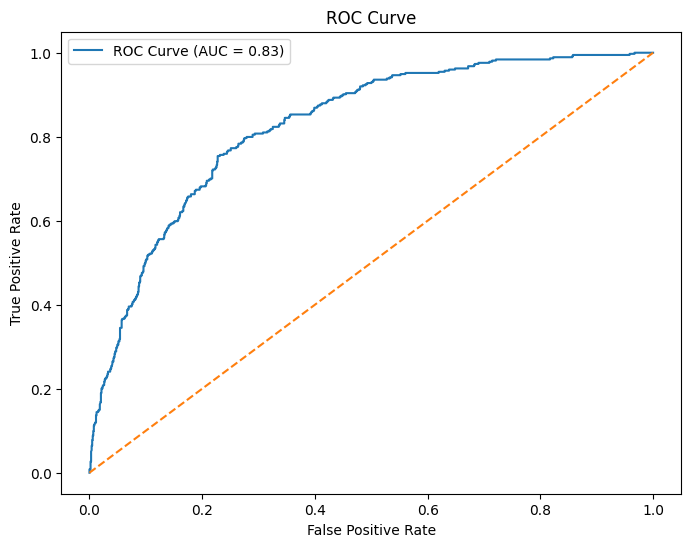


Top 15 Important Features:

                           Feature  Importance
0                           gender    9.428386
4                           tenure    8.014062
6                 PaperlessBilling    6.500916
2                          Partner    6.220946
13               MultipleLines_Yes    5.539040
9                  AvgMonthlySpend    5.147226
8                     TotalCharges    5.085776
17              OnlineSecurity_Yes    4.808345
7                   MonthlyCharges    4.621025
3                       Dependents    4.609283
19                OnlineBackup_Yes    4.564668
31  PaymentMethod_Electronic check    4.312055
23                 TechSupport_Yes    3.726736
28               Contract_One year    3.129074
27             StreamingMovies_Yes    3.078922


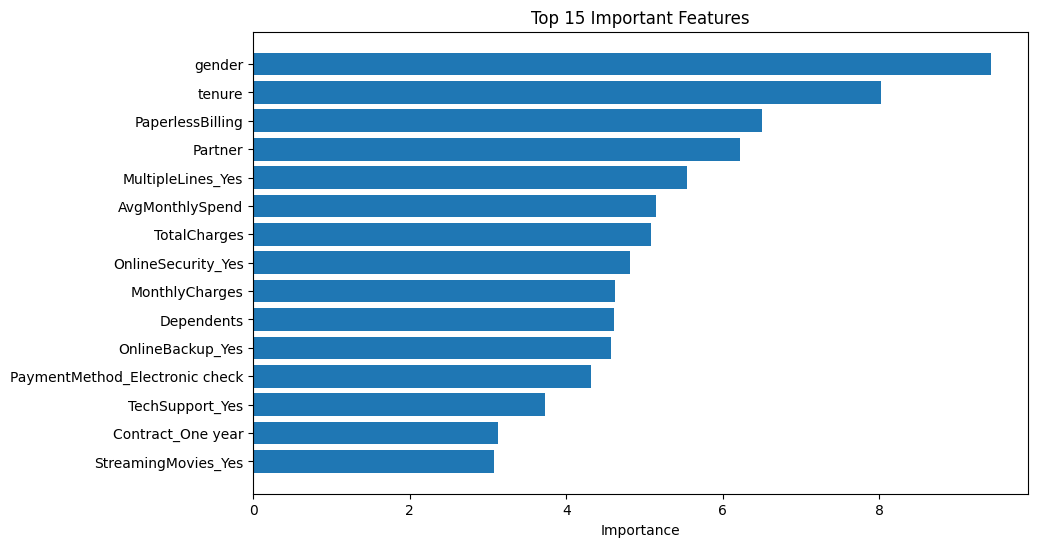

In [5]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
# FINAL THRESHOLD
# ==========================================

final_threshold = 0.40

y_final_pred = (
    y_prob >= final_threshold
).astype(int)

# ==========================================
# FINAL RESULTS
# ==========================================

print("\n===================================")
print("FINAL MODEL RESULTS")
print("===================================\n")

print(
    classification_report(
        y_test,
        y_final_pred
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        y_final_pred
    )
)

# ==========================================
# ROC CURVE
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        best_cat.feature_importances_
})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False
)

print("\nTop 15 Important Features:\n")

print(
    feature_importance.head(15)
)

# ==========================================
# PLOT FEATURE IMPORTANCE
# ==========================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(

    top_features["Feature"],

    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Important Features"
)

plt.xlabel("Importance")

plt.show()